## Introduction to NLU Machine Learning Methods

### What does NLU do?
NLU models seek to understand the underlying intention of a sentence.

In [1]:
# Packages Install
# !pip install nltk
# !pip install gensim
# nltk.download('punkt')
import pickle
import copy
import sklearn.manifold
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

In [2]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 800

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

### 1. Tokenization

In [3]:
# Wordpeice tokenization:
from nltk.tokenize import word_tokenize

# Tokenize input sentence:
input_sentence = "Today I will go to the library"
tokenized_word_vector = word_tokenize(input_sentence)

# Convert to numerical vector word embedding using existing dictionary 

### Different Types of Embedding

##### Goal of embedding: Transform tokenized sentence into numerical vector

<a href = "https://www.educative.io/blog/one-hot-encoding"><b>One-Hot embedding:</b></a> Sentence is transformed into one-hot vector corresponding to the vocabulary known to the model
ie. given vocabulary (red, white, blue), input "red white" is converted to [1,1,0]. Results in high dimensionality if set of vocabulary is high as well as a lot of zeros.


<b>Predetermined Embeddings: </b>
Each word in sentence is transformed into n-dimensional vector where n is large. These vectors are derived from a pretrained dictionary where each word is assigned an n-dimensional vector. Values in each vector are designed to have some sort of semantic similarity with similar word vectors in the dictionary. Results in a 2-dimensional embedding. Commonly used pre-trained embeddings are derived from word2vec or <a href = "https://aclanthology.org/D17-1024/">dict2vec</a>. 
Issue is that every word will have same embedding regardless of context.

<a href = "https://arxiv.org/pdf/1411.2738.pdf"><b>How does word2vec work?</b></a>
![](../img/word2vec.png)
BoW: Given a very large vocabulary of size V and a set of N sentences, a context word or window of words is transformed into an input vector using one-hot encoding. Nueral Network is trained where desired output is a one-hot vector corresponding to a target word (typically word that comes before or after the context words). Model is trained using SGD. Resulting encodings are obtained by passing in the one-hot encoding of the desired target word (vector with all zeros except for a one in the position corresponding to the desired word) into the trained model. Final layer nodes typically use a soft-max perceptron so all values in the output vector are between 0 and 1.

<b>Variations:</b>

<i>Continuous Bag of Words</i>: Given a set window size (in the figure below it is three), one-hot encoding is applied to each individual word in the window, then model is trained using the architecture below. Can be thought of as three seperate models sharing a similar final hidden layer.
![](../img/cbow.png)


<i>Skip-Gram</i>: Predicts the context words from target words. If window = 1, same as regular BoW except input and output are flipped. Resulting output layers are merged (average or sum) to form encodings.
![](../img/skip-gram.png)


### 2. Embedding

In [12]:
# get pretrained google word2vec
import gensim.downloader

# available models
print(list(gensim.downloader.info()['models'].keys()))

# use google news
# embedder = gensim.downloader.load('word2vec-google-news-300')
# pickle.dump(embedder, open("embed.pickle", "wb"))
embedder = pickle.load(open("embed.pickle", "rb"))

['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis']


In [42]:
word_embeddings = []
vocabulary = embedder.index_to_key

for token in tokenized_word_vector:
    if token in vocabulary:
        # get embedding from word2vec
        embedded_vector = (embedder[token])
    else:
        # if word doesn't exist, assign a zero vector. If too many zero vectors try lemmenization
        embedded_vector = [0]*300
    word_embeddings.append(embedded_vector)
    
word_embeddings

[array([-2.44140625e-01,  6.83593750e-02,  4.98046875e-02, -3.17382812e-02,
        -1.48315430e-02,  1.28906250e-01,  9.81445312e-02, -9.81445312e-02,
         2.81250000e-01,  2.83203125e-01, -1.29394531e-02, -9.15527344e-03,
        -4.76074219e-03,  1.91406250e-01, -3.14941406e-02,  6.68945312e-02,
         5.44433594e-02,  3.78417969e-02,  1.67846680e-03,  2.73437500e-02,
        -1.07910156e-01,  8.25195312e-02,  2.77343750e-01, -2.09960938e-02,
         6.59179688e-02,  3.17382812e-02, -3.27148438e-02,  5.71289062e-02,
         1.31835938e-01,  2.68554688e-02,  1.48437500e-01, -1.90429688e-02,
         3.88183594e-02, -2.38281250e-01,  1.12792969e-01,  5.02929688e-02,
        -1.39648438e-01,  1.27929688e-01, -4.44335938e-02, -1.07910156e-01,
        -4.69970703e-03, -7.86132812e-02, -4.80957031e-02,  7.66601562e-02,
         2.49023438e-01,  2.51464844e-02, -1.31835938e-01, -9.71679688e-02,
        -1.21093750e-01,  5.68847656e-02, -2.01171875e-01,  4.29687500e-02,
         1.2

### We can plot these word embeddings in 2D using a dimensionality reducing algorithm like PCA or T.sne

[t-SNE] Computing 6 nearest neighbors...
[t-SNE] Indexed 7 samples in 0.000s...
[t-SNE] Computed neighbors for 7 samples in 0.000s...
[t-SNE] Computed conditional probabilities for sample 7 / 7
[t-SNE] Mean sigma: 1125899906842624.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 46.536308
[t-SNE] KL divergence after 750 iterations: 0.158651


c:\users\randymi\appdata\local\programs\python\python39\lib\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
c:\users\randymi\appdata\local\programs\python\python39\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(


Text(0.5, 1.0, 'TSNE Plot')

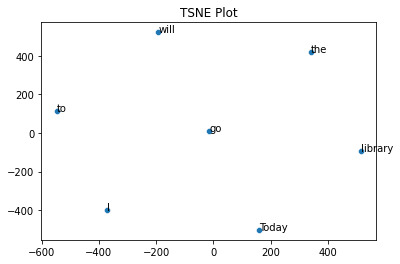

In [83]:
TSNE = sklearn.manifold.TSNE(n_components = 2, verbose = 1)
low_dimension = TSNE.fit_transform(word_embeddings)

p1 = sns.scatterplot(x = low_dimension[:,0], y = low_dimension[:,1])

for line in range(0,len(low_dimension)):
     p1.text(low_dimension[:,0][line]+1, low_dimension[:,1][line], 
     tokenized_word_vector[line], horizontalalignment='left', 
     size='medium', color='black')
        
plt.title("TSNE Plot")

### We can try this on multiple sentences to see if clustering occurs

In [319]:
# NLP embedding helper class

class NLP_embed:
    embedder = pickle.load(open("embed.pickle", "rb"))

    def __init__(self, sentences: list):
        self._sentences = sentences
        self._n_sentences = len(sentences)
        
    def tokenize(self):
        tokenized = []
        for i in range(self._n_sentences):
            tokenized.append(word_tokenize(self._sentences[i]))
        self._tokenized = tokenized
        
    def embed(self):
        embeds = []
        vocabulary = self.embedder.index_to_key
        for i in range(self._n_sentences):
            embed_sentence = []
            for token in self._tokenized[i]:
                if token in vocabulary:
                    # get embedding from word2vec
                    embedded_vector = self.embedder[token]
                else:
                    # if word doesn't exist, assign a zero vector. If too many zero vectors try lemmenization
                    embedded_vector = [0]*300
                embed_sentence.append(embedded_vector)
            embeds.append(embed_sentence)
        self._embeds = embeds
        
    def TSNE_reduce(self):
        TSNE = sklearn.manifold.TSNE(n_components = 2, verbose = 0)
        TSNE_embeds = [TSNE.fit_transform(i).tolist() for i in self._embeds]
        self._TSNE_embeds = TSNE_embeds
    
    # can't use numpy arrays since sentences are of varying length. List comprehension looks like spaghetti
    def plot_TSNE(self, words = True, size = 5):
        sentence_num = 0
        colors = sns.color_palette(palette ='bright', n_colors = self._n_sentences)
        plot_TSNE_embeds = copy.deepcopy(self._TSNE_embeds)
        for sentence in plot_TSNE_embeds:
            for word in sentence:
                word.append(sentence_num)
            sentence_num += 1
        
        d_TSNE_embeds = [elem for twod in plot_TSNE_embeds for elem in twod]
        d_TSNE_embeds = np.array(d_TSNE_embeds)
        
        d_tokens = [j for sub in self._tokenized for j in sub]
        
        p1 = sns.scatterplot(x = d_TSNE_embeds[:,0], y = d_TSNE_embeds[:,1], hue = d_TSNE_embeds[:,2], s = size, palette = colors)
        
        if words:
            for line in range(0,len(d_TSNE_embeds)):
                 p1.text(d_TSNE_embeds[:,0][line]+1, d_TSNE_embeds[:,1][line], 
                 d_tokens[line], horizontalalignment='left', 
                 size='medium', color=colors[int(d_TSNE_embeds[:,2][line])])
                    
        plt.legend().set_visible(False)
        plt.title("TSNE Plot")
        plt.show()

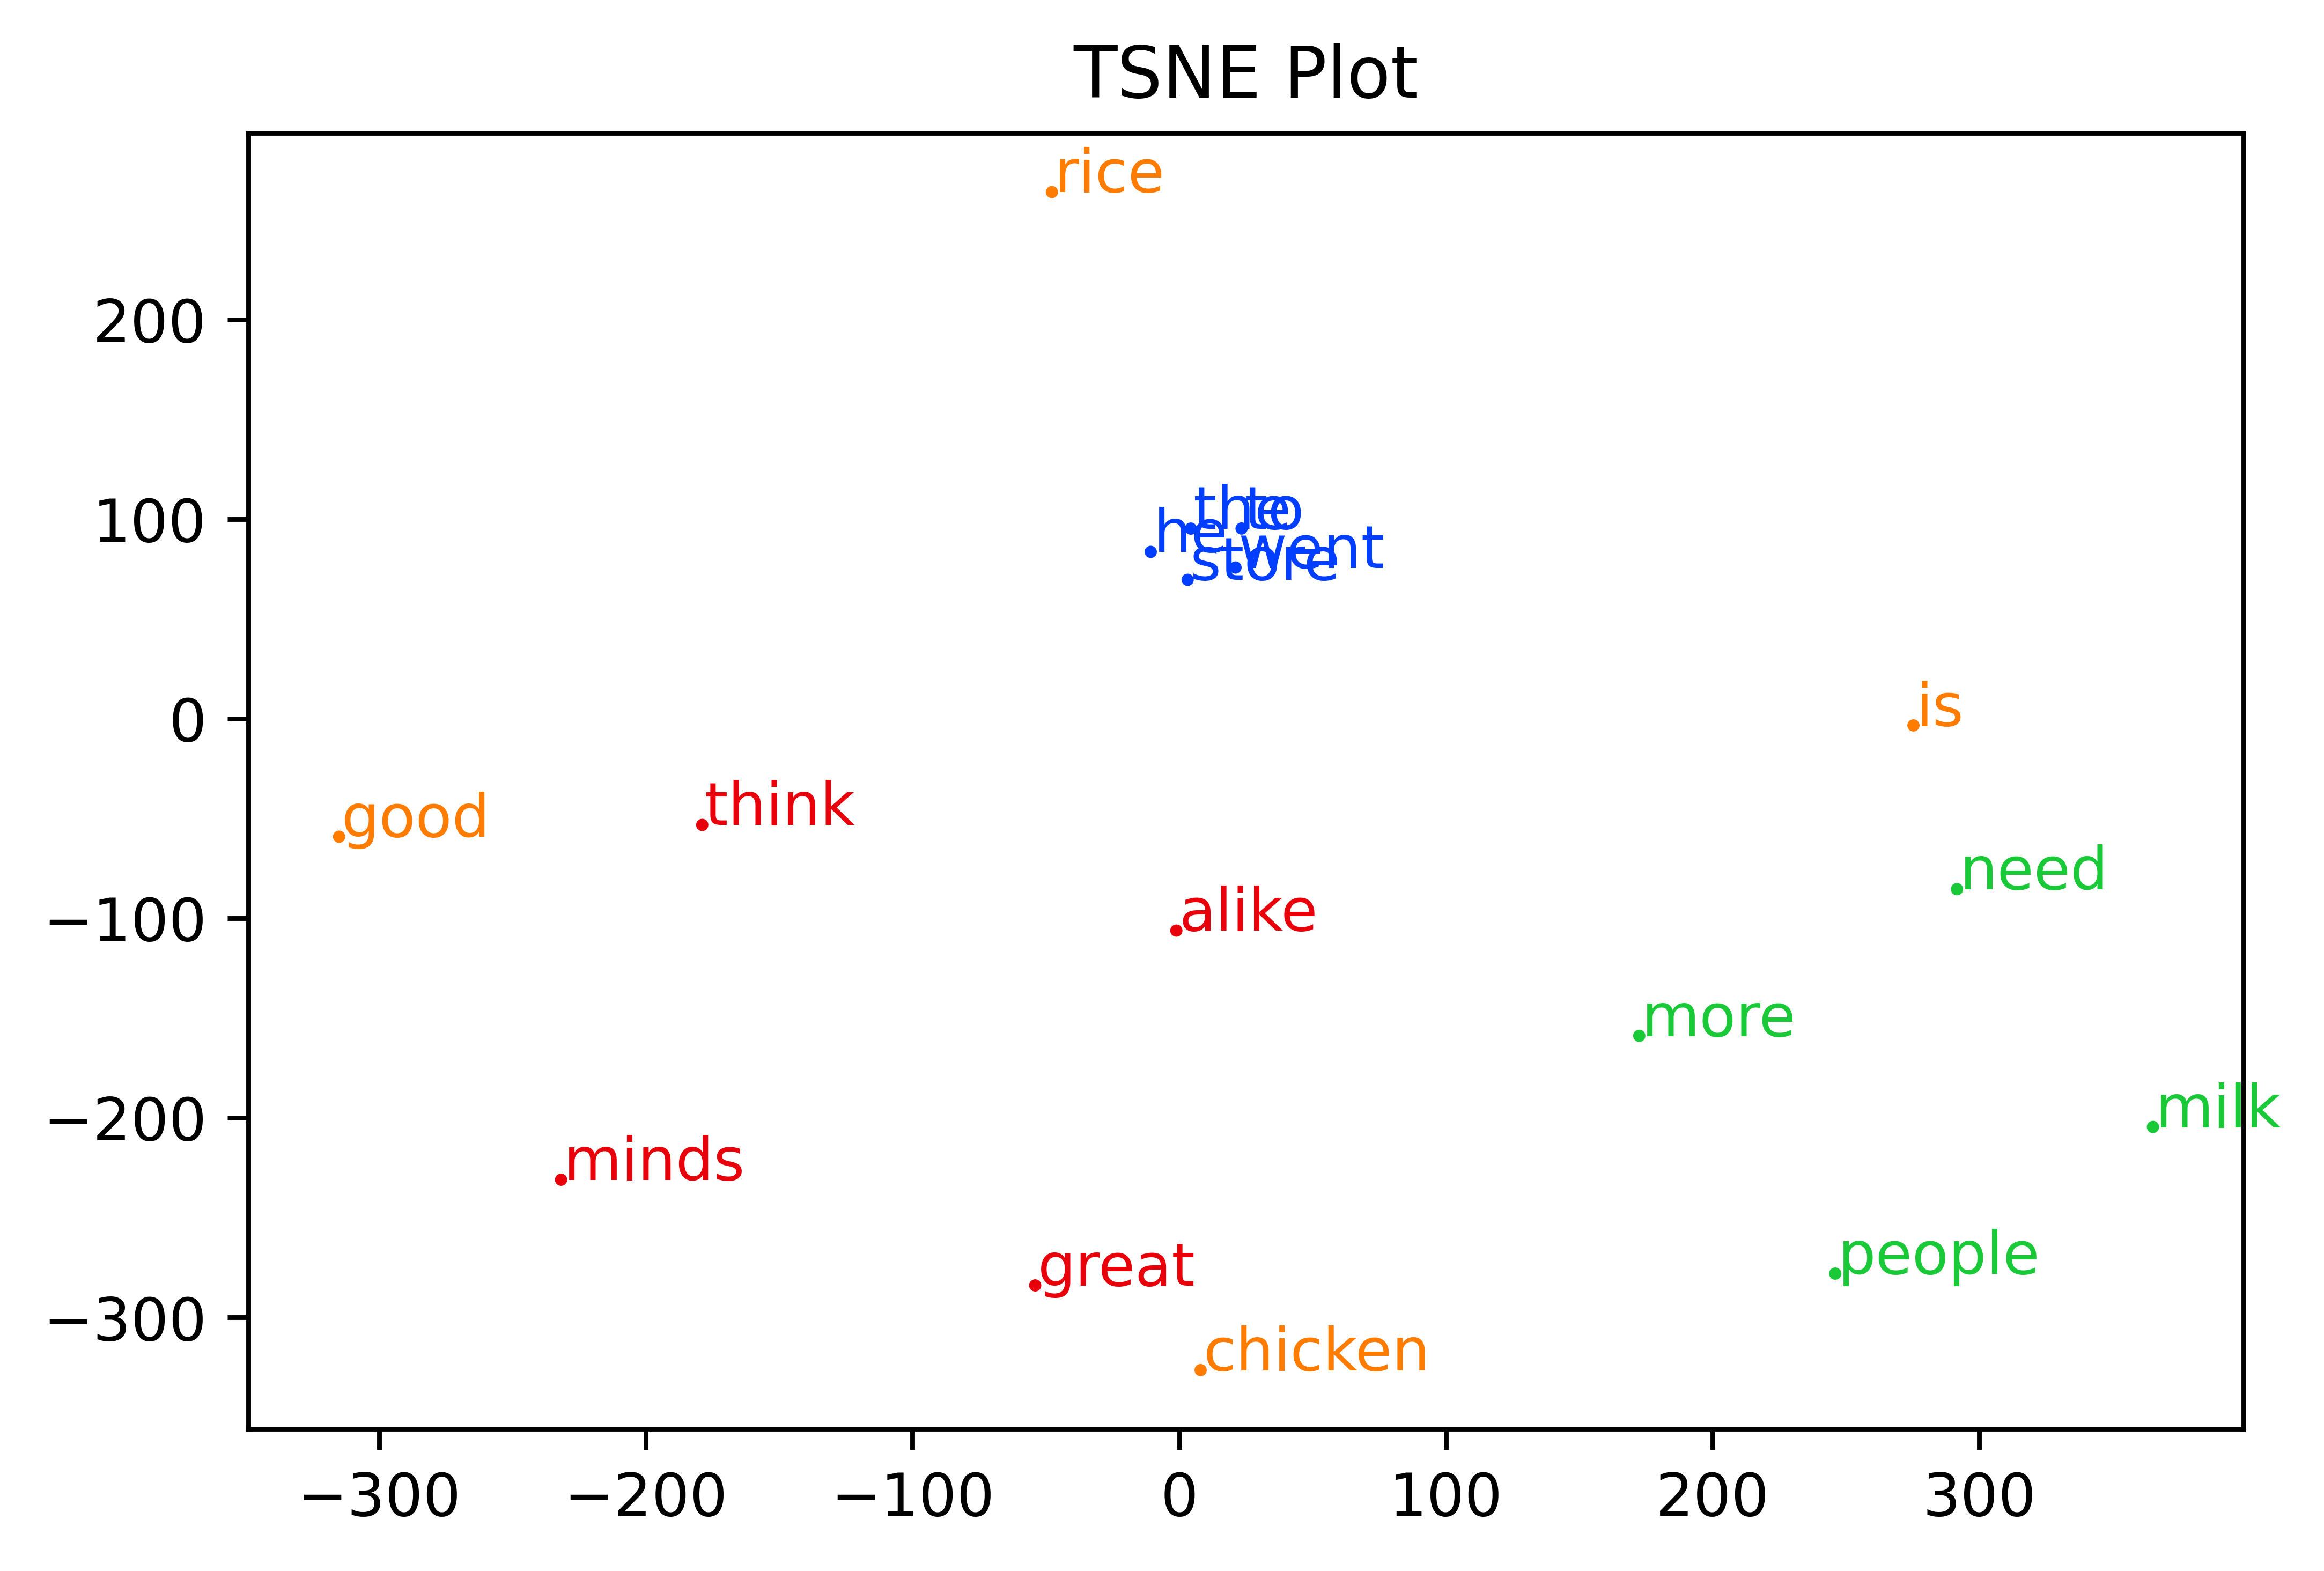

In [320]:
model = NLP_embed(["he went to the store", "chicken rice is good", "people need more milk", "great minds think alike"])
model.tokenize()
model.embed()
model.TSNE_reduce()
model.plot_TSNE()

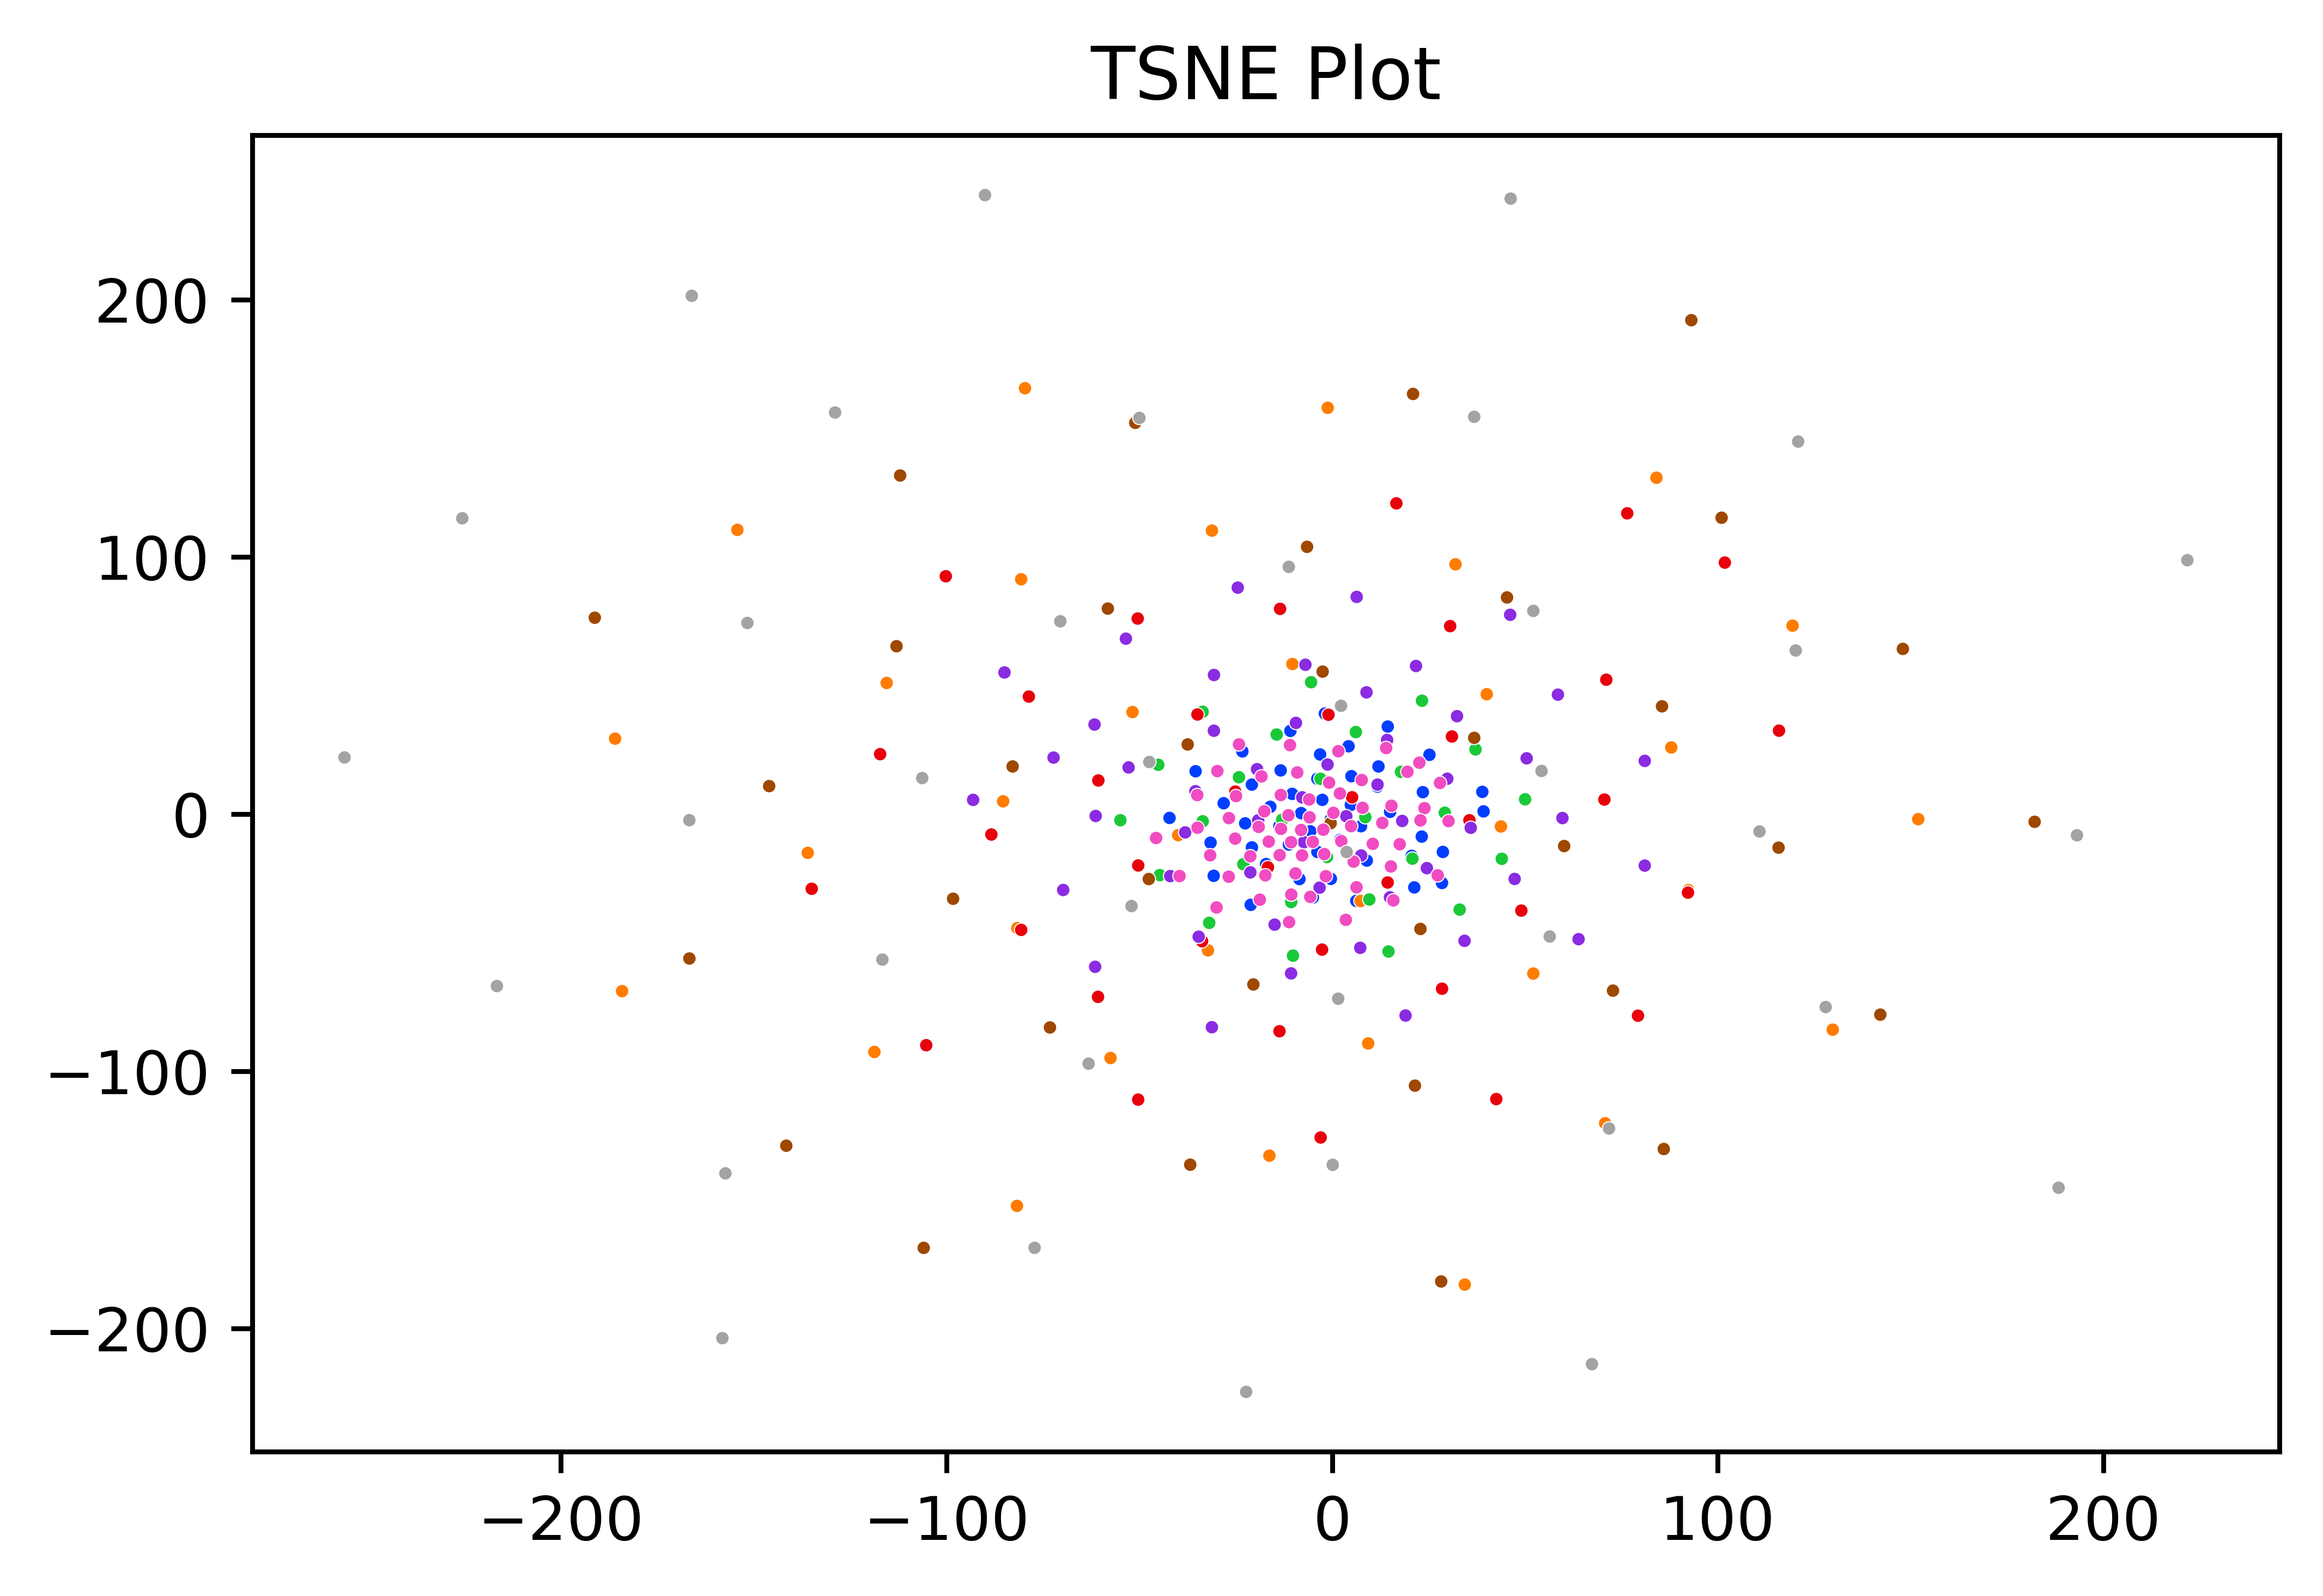

In [323]:
# Let's try it on random posts from the umich subreddit
sentences = ["I'm sorry if this is a stupid question, but I receive emails from a non-umich.edu email saying there are on-campus jobs offering $300 a week. I'm a freshman and don't know if this is a scam or if it is legitimate.",
             "I accepted admission to the MSI program early last week but haven't heard anything about registering for classes, orientation, etc. Have you been receiving communication through your umich email?",
             "Hi! I'm hoping that some people that have applied/are applying through AMCAS can help me out with some entering coursework questions that i have.",
             "I heard from a friend who has taken EECS 281 that he thinks the projects change from semester to semester so the projects that were given in Winter 22 will not be the same as Fall 22",
             "I've been looking for housing in Princeton recently, and I noticed that they have their own Craigslist-like posting board for housing/books/electronics. This was super neat, since I'd feel much more comfortable subletting or buying from another student rather than taking the chance on some random dude.",
             "Applied to Ross a few months ago to transfer, and have since accepted a consulting internship. Would anyone recommend sending admissions an email updating them, and if so, what email?",
             "So i'll take econ 101 next semester and i really hope to study ahead cuz my workload is superrr heavy next sem. I didn't find any resources of this course other than the syllabus and recommended text. Does anyone know any links to some material like recordings that I can access before class begins? thanks in advance!",
             "Im thinking of transferring CS to flint or Dearborn then to Ann Arbor. How hard is it? How long do I have to stay then apply to transfer? Did most of your credits transfer?",
            ]

model_reddit = NLP_embed(sentences)
model_reddit.tokenize()
model_reddit.embed()
model_reddit.TSNE_reduce()
model_reddit.plot_TSNE(words = False)


There doesn't seem to be any clustering occuring based on each sentence. The model also seems to be centered at 0,0 meaning a lot of the words probably didn't have a dictionary value in the embedding.